In [3]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

W moim projekcie oprogramuję otwarty schemat Rungego-Kutny rzędu 4. Macierze reguły są dane wzorami: $c$ ma postać:

$$ 
c=\begin{bmatrix}
0 \\[5pt]
\frac{1}{3} \\[5pt]
\frac {2}{3} \\[5pt]
1
\end{bmatrix},\quad
A=\begin{bmatrix}
0 & 0 & 0 & 0 \\[5pt]
\frac{1}{3} & 0 & 0 & 0 \\[5pt]
-\frac{1}{3} & 1 & 0 & 0 \\[5pt]
1 & -1 & 1 & 0 \\
\end{bmatrix},\quad
b=\begin{bmatrix}
\frac{1}{8} \\[5pt]
\frac{3}{8} \\[5pt]
\frac{3}{8} \\[5pt]
\frac{1}{8} \\
\end{bmatrix}. 
$$

Na tapet wezmę równanie logistyczne postaci: 
$$
\begin{cases}
x'(t) = x(t)\big(1 - x(t)\big), \quad t \in [0,1] \\
x(0) = \frac{1}{2}
\end{cases}.
$$

Rozwiązaniem tego problemu jest funkcja
$$
x(t)=\frac{1}{1+e^{-t}}.
$$

Ponieważ schemat ten jest otwarty, to na podstawie Twierdzenia 25. z wykładu 7:
"Jeżeli s-poziomowy otwarty schemat RK ma rząd p, to s ⩾ p", 
oraz twierdzenia 11. z wykładu 8:
"Niech schemat Rungego-Kutty spełnia warunek
Ae = c.
Schemat Rungego-Kutty ma rząd p wtedy i tylko wtedy, gdy spełnione są wszystkie warunki do p
włącznie z tabeli..." stwierdzamy, że omawiany schemat jest dokładnie rzędu 4. Sprawdzenie warunków tabeli znajduje się poniżej:

In [4]:
b = np.array([1/8, 3/8, 3/8, 1/8])
c = np.array([0, 1/3, 2/3, 1])
A = np.array([[0,0,0,0],[1/3,0,0,0],[-1/3,1,0,0],[1,-1,1,0]])
e = (np.array([1,1,1,1]))
c2 = np.array([0, 1/9, 4/9, 1])
c3 = np.array([0, 1/27, 8/27, 1])
c_diag = np.diag(c)
A2 = np.dot(A, A)

print(np.dot(b, e) == 1)
print(np.dot(b, c) == 1/2)
print(np.dot(b, c2) == 1/3)
print(np.dot(b, np.dot(A, c)) == 1/6)
print(np.dot(b, c3) == 1/4)
print(np.dot(b, np.dot(c_diag, np.dot(A, c))) == 1/8)
print(np.dot(b, np.dot(A, c2)) == 1/12)
print(np.dot(b, np.dot(A2, c)) == 1/24)

True
True
True
True
True
True
True
True


Teraz zajmę się wyznaczeniem obszaru stabilności. Zacznę od wyznaczenia funkcji stabilności, korzystając z twierdzenia 15. z wykładu 7.

In [23]:
z = sp.Symbol('z')

A = sp.Matrix(A)
b = sp.Matrix(b)
e = sp.Matrix(e)

I = sp.eye(4)

R_sp = sp.simplify((I - z*A + z*e*b.T).det() / (I - z*A).det()) # funkcja symboliczna z sympy
R = sp.lambdify(z, R_sp, 'numpy') # przekształcam na funkcję numeryczną

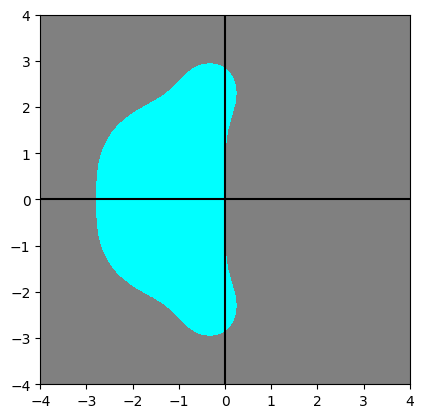

In [24]:
x = np.linspace(-4, 4, 1000)
y = np.linspace(-4, 4, 1000)
X, Y = np.meshgrid(x, y) # siatka punktów
Z = X + 1j*Y
mask = np.abs(R(Z))<1

fig, ax = plt.subplots()
ax.contourf(X, Y, mask, levels = 1, colors = ['grey', 'cyan'])
ax.set_aspect('equal') # ustawiam równe proporcje na obu osiach
ax.axhline(color = 'black') # koloruję osie na czarno
ax.axvline(color = 'black') #
plt.show()

Najpierw wyznaczę parametry $K_1,\dots,K_4$ za pomocą biblioteki sympy. 

In [25]:
xk = sp.symbols('xk')
h = sp.symbols('h')

K1 = xk-xk**2
# print(f'K1: {K1}\n')

K2 = sp.simplify((xk + (h/3)*K1)-(xk + (h/3)*K1)**2)
# print(f'K2: {K2}\n')

K3 = sp.simplify(xk - (h/3)*K1 + h*K2 - (xk - (h/3)*K1 + h*K2)**2)
# print(f'K3: {K3}\n')

K4 = sp.simplify(xk + h*K1 - h*K2 + h*K3 - (xk + h*K1 - h*K2 + h*K3)**2)
# print(f'K4: {K4}\n')

# K4.subs({xk: 0.5, h: 0.1}) - w ten sposób się odwołuję do wartości, gdyby mi to było potrzebne

K1 = lambda xk, h: -xk**2 + xk
K2 = lambda xk, h: xk*(-3*h*(xk - 1) - xk*(h*(xk - 1) - 3)**2 + 9)/9
K3 = lambda xk, h: xk*(27*h*(xk - 1) - 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) - xk*(3*h*(xk - 1) - h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 9)**2 + 81)/81
K4 = lambda xk, h: xk*(-6561*h*(xk - 1) + 729*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 81*h*(27*h*(xk - 1) - 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) - xk*(3*h*(xk - 1) - h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 9)**2 + 81) - xk*(-81*h*(xk - 1) + 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + h*(27*h*(xk - 1) - 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) - xk*(3*h*(xk - 1) - h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 9)**2 + 81) + 81)**2 + 6561)/6561


Skoro mam wyznaczone parametry $K_1,\dots,K_4,$ to mogę przejść do wyznaczenia siatki punktów i wartości w węzłach. 

/tmp/ipykernel_306505/1269658531.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


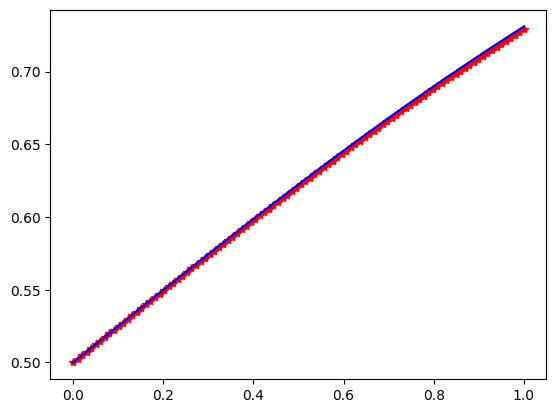

In [27]:
class metodaRungegoKutny:
    def __init__(self, n):
        self.n = n

    def rk(self):
        x=np.zeros(self.n)
        h=1/self.n
        x[0] = 1/2
        t=np.linspace(0, 1, self.n)
        for k in range(self.n-1):
            x[k+1] = x[k] + h*((1/8)*K1(x[k], h) + (3/8)*K2(x[k], h) + (3/8)*K3(x[k], h) + (1/8)*K4(x[k], h))
        return x
    
    def draw(self):
        f = lambda t: 1/(1 + np.exp(-t))
        t=np.linspace(0, 1, self.n)
        fig, ax = plt.subplots()
        ax.plot(t, self.rk(), color = 'r', marker = '*')
        ax.plot(t, f(t), color = 'b')
        fig.show()

o1 = metodaRungegoKutny(100)
o1.draw()